# 04 — Dutch Electricity Price Forecasting & Trading Signals

## Objective

Develop a realistic short-horizon electricity price forecasting model
for Dutch day-ahead electricity prices and convert forecasts into simple
algorithmic trading signals.

### Scope

- Market: Dutch day-ahead electricity market
- Bidding zone: 10YNL----------L
- Resolution: 15 minutes
- Forecast horizon: 24 hours (96 intervals)
- Model: LightGBM
- Evaluation: chronological train/test split
- Metrics: RMSE and MAE
- Output: forecasted prices and BUY / SELL / WAIT signals

The purpose is to demonstrate:

Market data → time-series features → price forecast → trading signal

This notebook is intentionally designed as a prototype,
not a production forecasting system.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# Imports and project configuration
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb


# Project root = parent directory of the notebooks folder
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

PRICE_FILE = (
    PROCESSED_DIR
    / "nl_day_ahead_prices_15min_2025-10_to_2026-08.csv"
)

FORECAST_FILE = (
    RESULTS_DIR
    / "price_forecast_24h_lightgbm.csv"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# Forecast configuration
FREQUENCY_MINUTES = 15
HORIZON_INTERVALS = 96
HORIZON_HOURS = 24

RANDOM_STATE = 42


print("Project root:")
print(PROJECT_ROOT)

print("\nPrice file:")
print(PRICE_FILE)

print("\nPrice file exists:", PRICE_FILE.exists())

print("\nForecast horizon:")
print(f"{HORIZON_INTERVALS} intervals = {HORIZON_HOURS} hours")

Project root:
C:\Users\USER\dutch-bess-flexibility-commercial-value-intelligence

Price file:
C:\Users\USER\dutch-bess-flexibility-commercial-value-intelligence\data\processed\nl_day_ahead_prices_15min_2025-10_to_2026-08.csv

Price file exists: True

Forecast horizon:
96 intervals = 24 hours


In [4]:
from pathlib import Path
import pandas as pd

# Project root (parent of notebooks)
PROJECT_ROOT = Path.cwd().parent

PRICE_FILE = PROJECT_ROOT / "data" / "processed" / "nl_day_ahead_prices_15min_2025-10_to_2026-08.csv"
RESULTS_DIR = PROJECT_ROOT / "results"

prices = pd.read_csv(PRICE_FILE)

print("Shape:", prices.shape)
display(prices.head())

Shape: (31942, 11)


,timestamp_utc,day_ahead_price_eur_mwh,resolution,timestamp_local,date,hour,month,month_name,day_of_week,price_change_eur_mwh,absolute_price_change_eur_mwh
0,2025-09-30 22:00:00+00:00,102.55,PT15M,2025-10-01 00:00:00+02:00,2025-10-01,0,10,October,Wednesday,NaN,NaN
1,2025-09-30 22:15:00+00:00,92.17,PT15M,2025-10-01 00:15:00+02:00,2025-10-01,0,10,October,Wednesday,-10.38,10.38
2,2025-09-30 22:30:00+00:00,82.69,PT15M,2025-10-01 00:30:00+02:00,2025-10-01,0,10,October,Wednesday,-9.48,9.48
3,2025-09-30 22:45:00+00:00,81.86,PT15M,2025-10-01 00:45:00+02:00,2025-10-01,0,10,October,Wednesday,-0.83,0.83
4,2025-09-30 23:00:00+00:00,89.54,PT15M,2025-10-01 01:00:00+02:00,2025-10-01,1,10,October,Wednesday,7.68,7.68


In [5]:
# ============================================================
# Identify timestamp and price columns
# ============================================================

print("Column names:")
for i, col in enumerate(prices.columns):
    print(f"{i}: {col}")

print("\nSample values:")
display(prices.head(10))

print("\nMissing values:")
display(prices.isna().sum())

print("\nDuplicate rows:")
print(prices.duplicated().sum())

Column names:
0: timestamp_utc
1: day_ahead_price_eur_mwh
2: resolution
3: timestamp_local
4: date
5: hour
6: month
7: month_name
8: day_of_week
9: price_change_eur_mwh
10: absolute_price_change_eur_mwh

Sample values:


,timestamp_utc,day_ahead_price_eur_mwh,resolution,timestamp_local,date,hour,month,month_name,day_of_week,price_change_eur_mwh,absolute_price_change_eur_mwh
0,2025-09-30 22:00:00+00:00,102.55,PT15M,2025-10-01 00:00:00+02:00,2025-10-01,0,10,October,Wednesday,NaN,NaN
1,2025-09-30 22:15:00+00:00,92.17,PT15M,2025-10-01 00:15:00+02:00,2025-10-01,0,10,October,Wednesday,-10.38,10.38
2,2025-09-30 22:30:00+00:00,82.69,PT15M,2025-10-01 00:30:00+02:00,2025-10-01,0,10,October,Wednesday,-9.48,9.48
3,2025-09-30 22:45:00+00:00,81.86,PT15M,2025-10-01 00:45:00+02:00,2025-10-01,0,10,October,Wednesday,-0.83,0.83
4,2025-09-30 23:00:00+00:00,89.54,PT15M,2025-10-01 01:00:00+02:00,2025-10-01,1,10,October,Wednesday,7.68,7.68
5,2025-09-30 23:15:00+00:00,84.93,PT15M,2025-10-01 01:15:00+02:00,2025-10-01,1,10,October,Wednesday,-4.61,4.61
6,2025-09-30 23:30:00+00:00,83.56,PT15M,2025-10-01 01:30:00+02:00,2025-10-01,1,10,October,Wednesday,-1.37,1.37
7,2025-09-30 23:45:00+00:00,81.69,PT15M,2025-10-01 01:45:00+02:00,2025-10-01,1,10,October,Wednesday,-1.87,1.87
8,2025-10-01 00:00:00+00:00,81.87,PT15M,2025-10-01 02:00:00+02:00,2025-10-01,2,10,October,Wednesday,0.18,0.18
9,2025-10-01 00:15:00+00:00,81.51,PT15M,2025-10-01 02:15:00+02:00,2025-10-01,2,10,October,Wednesday,-0.36,0.36



Missing values:


timestamp_utc                    0
day_ahead_price_eur_mwh          0
resolution                       0
timestamp_local                  0
date                             0
hour                             0
month                            0
month_name                       0
day_of_week                      0
price_change_eur_mwh             1
absolute_price_change_eur_mwh    1
dtype: int64


Duplicate rows:
0


In [6]:
# ============================================================
# Timestamp parsing and chronological validation
# ============================================================

df = prices.copy()

# Parse UTC timestamp
df["timestamp_utc"] = pd.to_datetime(
    df["timestamp_utc"],
    utc=True
)

# Convert UTC to Amsterdam time.
# This correctly handles CET/CEST daylight-saving changes.
df["timestamp_local"] = (
    df["timestamp_utc"]
    .dt.tz_convert("Europe/Amsterdam")
)

# Sort chronologically
df = (
    df
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)


print("First UTC timestamp:")
print(df["timestamp_utc"].iloc[0])

print("\nLast UTC timestamp:")
print(df["timestamp_utc"].iloc[-1])

print("\nFirst Amsterdam timestamp:")
print(df["timestamp_local"].iloc[0])

print("\nLast Amsterdam timestamp:")
print(df["timestamp_local"].iloc[-1])

print("\nNumber of observations:")
print(len(df))

print("\nDuplicate UTC timestamps:")
print(df["timestamp_utc"].duplicated().sum())


# ------------------------------------------------------------
# Check chronological spacing
# ------------------------------------------------------------

time_deltas = (
    df["timestamp_utc"]
    .diff()
    .dropna()
)

print("\nObserved time intervals:")
print(time_deltas.value_counts().head(10))


# ------------------------------------------------------------
# Check actual calendar coverage
# ------------------------------------------------------------

print("\nUTC calendar coverage:")
print(
    df["timestamp_utc"].min().date(),
    "to",
    df["timestamp_utc"].max().date()
)

print("\nAmsterdam calendar coverage:")
print(
    df["timestamp_local"].min().date(),
    "to",
    df["timestamp_local"].max().date()
)

First UTC timestamp:
2025-09-30 22:00:00+00:00

Last UTC timestamp:
2026-09-01 21:45:00+00:00

First Amsterdam timestamp:
2025-10-01 00:00:00+02:00

Last Amsterdam timestamp:
2026-09-01 23:45:00+02:00

Number of observations:
31942

Duplicate UTC timestamps:
0

Observed time intervals:
timestamp_utc
0 days 00:15:00    31735
0 days 00:30:00      151
0 days 00:45:00       32
0 days 01:00:00       13
0 days 01:15:00        3
0 days 01:45:00        2
0 days 01:30:00        2
0 days 02:15:00        2
0 days 02:45:00        1
Name: count, dtype: int64

UTC calendar coverage:
2025-09-30 to 2026-09-01

Amsterdam calendar coverage:
2025-10-01 to 2026-09-01


Price column: day_ahead_price_eur_mwh

Price statistics:


count    31942.000000
mean        99.565846
std         57.120133
min       -499.620000
25%         77.100000
50%        100.045000
75%        128.917500
max        902.470000
Name: day_ahead_price_eur_mwh, dtype: float64


Missing prices:
0

Price range:
Minimum: -499.62 €/MWh
Maximum: 902.47 €/MWh


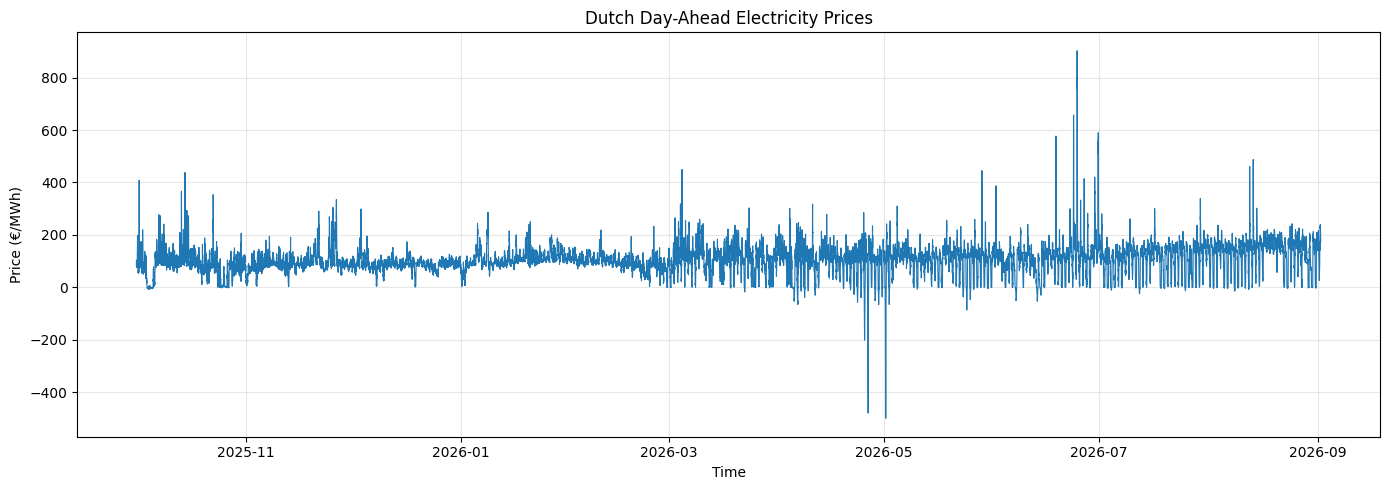

In [7]:
# ============================================================
# Price series validation
# ============================================================

PRICE_COL = "day_ahead_price_eur_mwh"

print("Price column:", PRICE_COL)

print("\nPrice statistics:")
display(df[PRICE_COL].describe())

print("\nMissing prices:")
print(df[PRICE_COL].isna().sum())

print("\nPrice range:")
print(
    f"Minimum: {df[PRICE_COL].min():.2f} €/MWh"
)

print(
    f"Maximum: {df[PRICE_COL].max():.2f} €/MWh"
)


# Visual inspection of the full historical series
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp_utc"],
    df[PRICE_COL],
    linewidth=0.8
)

plt.title("Dutch Day-Ahead Electricity Prices")
plt.xlabel("Time")
plt.ylabel("Price (€/MWh)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Time-series preparation and feature engineering
# ============================================================

PRICE_COL = "day_ahead_price_eur_mwh"

# Keep only the columns needed for forecasting
model_df = df[
    [
        "timestamp_utc",
        "timestamp_local",
        PRICE_COL
    ]
].copy()


# ------------------------------------------------------------
# Create a regular 15-minute UTC time grid
# ------------------------------------------------------------

full_time_index = pd.date_range(
    start=model_df["timestamp_utc"].min(),
    end=model_df["timestamp_utc"].max(),
    freq="15min",
    tz="UTC"
)

model_df = (
    model_df
    .set_index("timestamp_utc")
    .reindex(full_time_index)
    .rename_axis("timestamp_utc")
    .reset_index()
)


# Recreate Amsterdam local time after reindexing
model_df["timestamp_local"] = (
    model_df["timestamp_utc"]
    .dt.tz_convert("Europe/Amsterdam")
)


# ------------------------------------------------------------
# Identify missing market observations
# ------------------------------------------------------------

missing_price_count = model_df[PRICE_COL].isna().sum()

print("Expected 15-minute observations:")
print(len(model_df))

print("\nMissing price observations after regularization:")
print(missing_price_count)

print(
    "\nMissing percentage:",
    f"{100 * missing_price_count / len(model_df):.3f}%"
)


# ------------------------------------------------------------
# Calendar features
# ------------------------------------------------------------

model_df["hour"] = model_df["timestamp_local"].dt.hour
model_df["minute"] = model_df["timestamp_local"].dt.minute

model_df["quarter_hour"] = (
    model_df["hour"] * 4
    + model_df["minute"] // 15
)

model_df["day_of_week_num"] = (
    model_df["timestamp_local"].dt.dayofweek
)

model_df["month_num"] = (
    model_df["timestamp_local"].dt.month
)


# Cyclical time encoding

model_df["hour_sin"] = np.sin(
    2 * np.pi * model_df["quarter_hour"] / 96
)

model_df["hour_cos"] = np.cos(
    2 * np.pi * model_df["quarter_hour"] / 96
)

model_df["dow_sin"] = np.sin(
    2 * np.pi * model_df["day_of_week_num"] / 7
)

model_df["dow_cos"] = np.cos(
    2 * np.pi * model_df["day_of_week_num"] / 7
)


# ------------------------------------------------------------
# Lag features
# ------------------------------------------------------------

model_df["lag_1"] = model_df[PRICE_COL].shift(1)

model_df["lag_4"] = model_df[PRICE_COL].shift(4)

model_df["lag_12"] = model_df[PRICE_COL].shift(12)

model_df["lag_24"] = model_df[PRICE_COL].shift(24)

model_df["lag_48"] = model_df[PRICE_COL].shift(48)

model_df["lag_96"] = model_df[PRICE_COL].shift(96)

model_df["lag_192"] = model_df[PRICE_COL].shift(192)

model_df["lag_672"] = model_df[PRICE_COL].shift(672)


# ------------------------------------------------------------
# Rolling historical statistics
#
# Shift first so the current price is never included.
# ------------------------------------------------------------

past_prices = model_df[PRICE_COL].shift(1)

model_df["rolling_mean_1h"] = (
    past_prices.rolling(4).mean()
)

model_df["rolling_std_1h"] = (
    past_prices.rolling(4).std()
)

model_df["rolling_mean_6h"] = (
    past_prices.rolling(24).mean()
)

model_df["rolling_std_6h"] = (
    past_prices.rolling(24).std()
)

model_df["rolling_mean_24h"] = (
    past_prices.rolling(96).mean()
)

model_df["rolling_std_24h"] = (
    past_prices.rolling(96).std()
)


print("\nFeature dataset created.")
print("Shape:", model_df.shape)

print("\nTotal missing values across all columns:")
print(model_df.isna().sum().sum())

print("\nMissing values by column:")
display(
    model_df.isna().sum()
    .sort_values(ascending=False)
    .head(15)
)

Expected 15-minute observations:
32256

Missing price observations after regularization:
314

Missing percentage: 0.973%

Feature dataset created.
Shape: (32256, 26)

Total missing values across all columns:
36123

Missing values by column:


rolling_std_24h            11567
rolling_mean_24h           11567
rolling_std_6h              3695
rolling_mean_6h             3695
lag_672                      978
rolling_std_1h               868
rolling_mean_1h              868
lag_192                      502
lag_96                       410
lag_48                       362
lag_24                       338
lag_12                       326
lag_4                        318
lag_1                        315
day_ahead_price_eur_mwh      314
dtype: int64

In [9]:
# ============================================================
# Restrict to the existing project analysis period
# ============================================================

ANALYSIS_START = pd.Timestamp(
    "2025-10-01 00:00:00",
    tz="Europe/Amsterdam"
)

ANALYSIS_END = pd.Timestamp(
    "2026-08-31 23:45:00",
    tz="Europe/Amsterdam"
)


analysis_mask = (
    (model_df["timestamp_local"] >= ANALYSIS_START)
    & (model_df["timestamp_local"] <= ANALYSIS_END)
)

model_df = (
    model_df.loc[analysis_mask]
    .copy()
    .reset_index(drop=True)
)


print("Analysis period:")
print(model_df["timestamp_local"].iloc[0])
print("to")
print(model_df["timestamp_local"].iloc[-1])

print("\nRows:")
print(len(model_df))

print("\nMissing prices:")
print(model_df[PRICE_COL].isna().sum())

Analysis period:
2025-10-01 00:00:00+02:00
to
2026-08-31 23:45:00+02:00

Rows:
32160

Missing prices:
314


In [10]:
# ============================================================
# Define model features
# ============================================================

FEATURE_COLS = [
    # Calendar / cyclical features
    "quarter_hour",
    "day_of_week_num",
    "month_num",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    # Recent price history
    "lag_1",
    "lag_4",
    "lag_12",
    "lag_24",
    "lag_48",
    "lag_96",
    "lag_192",
    "lag_672",

    # Rolling price statistics
    "rolling_mean_1h",
    "rolling_std_1h",
    "rolling_mean_6h",
    "rolling_std_6h",
    "rolling_mean_24h",
    "rolling_std_24h",
]


print("Number of base features:")
print(len(FEATURE_COLS))

print("\nFeatures:")
for feature in FEATURE_COLS:
    print("-", feature)

Number of base features:
21

Features:
- quarter_hour
- day_of_week_num
- month_num
- hour_sin
- hour_cos
- dow_sin
- dow_cos
- lag_1
- lag_4
- lag_12
- lag_24
- lag_48
- lag_96
- lag_192
- lag_672
- rolling_mean_1h
- rolling_std_1h
- rolling_mean_6h
- rolling_std_6h
- rolling_mean_24h
- rolling_std_24h


In [11]:
# ============================================================
# Identify valid 24-hour forecasting origins
# ============================================================

# All model features must be available
features_available = (
    model_df[FEATURE_COLS]
    .notna()
    .all(axis=1)
)


# ------------------------------------------------------------
# Check that all 96 future prices exist
# ------------------------------------------------------------

future_price_complete = pd.Series(
    True,
    index=model_df.index
)

for horizon in range(1, HORIZON_INTERVALS + 1):
    future_price_complete &= (
        model_df[PRICE_COL]
        .shift(-horizon)
        .notna()
    )


valid_origin_mask = (
    features_available
    & model_df[PRICE_COL].notna()
    & future_price_complete
)


valid_origins = model_df.loc[
    valid_origin_mask
].copy()


print("Total rows:")
print(len(model_df))

print("\nRows with complete model features:")
print(features_available.sum())

print("\nValid 24-hour forecast origins:")
print(len(valid_origins))

print("\nPercentage of usable origins:")
print(
    f"{100 * len(valid_origins) / len(model_df):.2f}%"
)

print("\nFirst valid origin:")
print(valid_origins["timestamp_local"].iloc[0])

print("\nLast valid origin:")
print(valid_origins["timestamp_local"].iloc[-1])

Total rows:
32160

Rows with complete model features:
20070

Valid 24-hour forecast origins:
14014

Percentage of usable origins:
43.58%

First valid origin:
2025-10-08 00:00:00+02:00

Last valid origin:
2026-08-29 13:30:00+02:00


In [12]:
# ============================================================
# Chronological train/test split
# ============================================================

TEST_START = pd.Timestamp(
    "2026-08-01 00:00:00",
    tz="Europe/Amsterdam"
)

TRAIN_END = TEST_START - pd.Timedelta(minutes=15)


train_origins = valid_origins[
    valid_origins["timestamp_local"] < TEST_START
].copy()

test_origins = valid_origins[
    valid_origins["timestamp_local"] >= TEST_START
].copy()


print("Training period:")
print(train_origins["timestamp_local"].min())
print("to")
print(train_origins["timestamp_local"].max())

print("\nTraining origins:")
print(len(train_origins))

print("\nTest period:")
print(test_origins["timestamp_local"].min())
print("to")
print(test_origins["timestamp_local"].max())

print("\nTest origins:")
print(len(test_origins))

Training period:
2025-10-08 00:00:00+02:00
to
2026-07-31 13:15:00+02:00

Training origins:
13108

Test period:
2026-08-07 16:30:00+02:00
to
2026-08-29 13:30:00+02:00

Test origins:
906


In [13]:
# ============================================================
# Build multi-horizon training dataset
# ============================================================

def build_multihorizon_dataset(origins, source_df):
    """
    Convert forecast origins into one row per forecast horizon.

    Each row contains:
        - features known at forecast origin
        - forecast horizon (1...96)
        - actual future price
    """

    rows = []

    source_indexed = (
        source_df
        .set_index("timestamp_utc")
    )

    for _, origin_row in origins.iterrows():

        origin_time = origin_row["timestamp_utc"]

        base_features = (
            origin_row[FEATURE_COLS]
            .to_dict()
        )

        for horizon in range(1, HORIZON_INTERVALS + 1):

            target_time = (
                origin_time
                + pd.Timedelta(
                    minutes=FREQUENCY_MINUTES * horizon
                )
            )

            if target_time not in source_indexed.index:
                continue

            target_price = source_indexed.loc[
                target_time,
                PRICE_COL
            ]

            if pd.isna(target_price):
                continue

            row = base_features.copy()

            row["forecast_horizon"] = horizon
            row["target_price"] = target_price
            row["origin_timestamp"] = origin_time

            rows.append(row)

    return pd.DataFrame(rows)


train_supervised = build_multihorizon_dataset(
    train_origins,
    model_df
)

test_supervised = build_multihorizon_dataset(
    test_origins,
    model_df
)


print("Training dataset shape:")
print(train_supervised.shape)

print("\nTest dataset shape:")
print(test_supervised.shape)

print("\nTraining horizons:")
print(
    train_supervised["forecast_horizon"]
    .min(),
    "to",
    train_supervised["forecast_horizon"].max()
)

print("\nTest horizons:")
print(
    test_supervised["forecast_horizon"]
    .min(),
    "to",
    test_supervised["forecast_horizon"].max()
)

Training dataset shape:
(1258368, 24)

Test dataset shape:
(86976, 24)

Training horizons:
1 to 96

Test horizons:
1 to 96


In [14]:
# ============================================================
# Prepare LightGBM training matrices
# ============================================================

MODEL_FEATURES = FEATURE_COLS + [
    "forecast_horizon"
]


X_train = train_supervised[MODEL_FEATURES]
y_train = train_supervised["target_price"]

X_test = test_supervised[MODEL_FEATURES]
y_test = test_supervised["target_price"]


print("X_train:")
print(X_train.shape)

print("\ny_train:")
print(y_train.shape)

print("\nX_test:")
print(X_test.shape)

print("\ny_test:")
print(y_test.shape)

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_test:", X_test.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_test:", y_test.isna().sum())

X_train:
(1258368, 22)

y_train:
(1258368,)

X_test:
(86976, 22)

y_test:
(86976,)

Missing values:
X_train: 0
X_test: 0
y_train: 0
y_test: 0


In [15]:
# ============================================================
# Train LightGBM multi-horizon price model
# ============================================================

model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)


model.fit(
    X_train,
    y_train
)


print("LightGBM training completed.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.129714 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3940
[LightGBM] [Info] Number of data points in the train set: 1258368, number of used features: 22
[LightGBM] [Info] Start training from score 105.844519
LightGBM training completed.


In [16]:
# ============================================================
# Generate test-set forecasts
# ============================================================

test_supervised = test_supervised.copy()

test_supervised["predicted_price"] = (
    model.predict(X_test)
)


print("Forecasts generated.")

display(
    test_supervised[
        [
            "origin_timestamp",
            "forecast_horizon",
            "target_price",
            "predicted_price"
        ]
    ].head(20)
)

Forecasts generated.


,origin_timestamp,forecast_horizon,target_price,predicted_price
0,2026-08-07 14:30:00+00:00,1,99.81,109.099204
1,2026-08-07 14:30:00+00:00,2,100.68,109.099204
2,2026-08-07 14:30:00+00:00,3,107.89,110.709190
3,2026-08-07 14:30:00+00:00,4,120.48,112.733507
4,2026-08-07 14:30:00+00:00,5,130.47,118.003817
5,2026-08-07 14:30:00+00:00,6,121.31,124.566258
6,2026-08-07 14:30:00+00:00,7,138.04,134.266057
7,2026-08-07 14:30:00+00:00,8,145.65,134.457880
8,2026-08-07 14:30:00+00:00,9,162.09,139.067323
9,2026-08-07 14:30:00+00:00,10,145.82,151.012913


In [17]:
# ============================================================
# Forecast accuracy metrics
# ============================================================

rmse = np.sqrt(
    mean_squared_error(
        test_supervised["target_price"],
        test_supervised["predicted_price"]
    )
)

mae = mean_absolute_error(
    test_supervised["target_price"],
    test_supervised["predicted_price"]
)


print("LightGBM 24-hour forecasting performance")
print("=" * 50)

print(f"RMSE: {rmse:.2f} €/MWh")
print(f"MAE:  {mae:.2f} €/MWh")

LightGBM 24-hour forecasting performance
RMSE: 42.24 €/MWh
MAE:  31.20 €/MWh


In [18]:
# ============================================================
# Forecast performance by horizon
# ============================================================

horizon_metrics = []

for horizon in range(1, HORIZON_INTERVALS + 1):

    horizon_data = test_supervised[
        test_supervised["forecast_horizon"] == horizon
    ]

    horizon_rmse = np.sqrt(
        mean_squared_error(
            horizon_data["target_price"],
            horizon_data["predicted_price"]
        )
    )

    horizon_mae = mean_absolute_error(
        horizon_data["target_price"],
        horizon_data["predicted_price"]
    )

    horizon_metrics.append(
        {
            "forecast_horizon": horizon,
            "hours_ahead": horizon * FREQUENCY_MINUTES / 60,
            "rmse_eur_mwh": horizon_rmse,
            "mae_eur_mwh": horizon_mae
        }
    )


horizon_metrics = pd.DataFrame(horizon_metrics)


display(horizon_metrics.head(10))

print("\nSelected horizons:")
display(
    horizon_metrics[
        horizon_metrics["forecast_horizon"].isin(
            [1, 4, 12, 24, 48, 72, 96]
        )
    ]
)

,forecast_horizon,hours_ahead,rmse_eur_mwh,mae_eur_mwh
0,1,0.25,24.563031,17.667521
1,2,0.50,24.427025,17.004484
2,3,0.75,24.302259,16.552931
3,4,1.00,25.333256,17.477432
4,5,1.25,25.944412,18.425638
5,6,1.50,25.921476,18.993673
6,7,1.75,26.652089,19.668475
7,8,2.00,28.161474,20.873586
8,9,2.25,29.512268,21.621577
9,10,2.50,30.136789,22.264152



Selected horizons:


,forecast_horizon,hours_ahead,rmse_eur_mwh,mae_eur_mwh
0,1,0.25,24.563031,17.667521
3,4,1.00,25.333256,17.477432
11,12,3.00,32.982581,24.532227
23,24,6.00,36.264624,28.381805
47,48,12.00,46.077880,36.026676
71,72,18.00,41.633898,32.038004
95,96,24.00,35.471520,28.345890


In [19]:
# ============================================================
# Naive persistence benchmark
# ============================================================

# Latest observed price at each forecast origin
origin_prices = (
    test_origins[
        [
            "timestamp_utc",
            PRICE_COL
        ]
    ]
    .rename(
        columns={
            PRICE_COL: "naive_price"
        }
    )
)


# Merge naive forecast into the supervised test data
test_supervised = test_supervised.merge(
    origin_prices,
    left_on="origin_timestamp",
    right_on="timestamp_utc",
    how="left"
)


naive_rmse = np.sqrt(
    mean_squared_error(
        test_supervised["target_price"],
        test_supervised["naive_price"]
    )
)

naive_mae = mean_absolute_error(
    test_supervised["target_price"],
    test_supervised["naive_price"]
)


print("Naive persistence benchmark")
print("=" * 50)

print(f"RMSE: {naive_rmse:.2f} €/MWh")
print(f"MAE:  {naive_mae:.2f} €/MWh")


print("\nLightGBM")
print("=" * 50)

print(f"RMSE: {rmse:.2f} €/MWh")
print(f"MAE:  {mae:.2f} €/MWh")

Naive persistence benchmark
RMSE: 72.56 €/MWh
MAE:  51.73 €/MWh

LightGBM
RMSE: 42.24 €/MWh
MAE:  31.20 €/MWh


In [20]:
# ============================================================
# Model comparison
# ============================================================

rmse_improvement = (
    1 - rmse / naive_rmse
) * 100

mae_improvement = (
    1 - mae / naive_mae
) * 100


comparison = pd.DataFrame(
    {
        "model": [
            "Naive persistence",
            "LightGBM"
        ],
        "RMSE_eur_mwh": [
            naive_rmse,
            rmse
        ],
        "MAE_eur_mwh": [
            naive_mae,
            mae
        ]
    }
)


display(comparison)


print(
    f"\nRMSE improvement vs naive: "
    f"{rmse_improvement:.2f}%"
)

print(
    f"MAE improvement vs naive: "
    f"{mae_improvement:.2f}%"
)

,model,RMSE_eur_mwh,MAE_eur_mwh
0,Naive persistence,72.556446,51.730019
1,LightGBM,42.235344,31.195713



RMSE improvement vs naive: 41.79%
MAE improvement vs naive: 39.70%


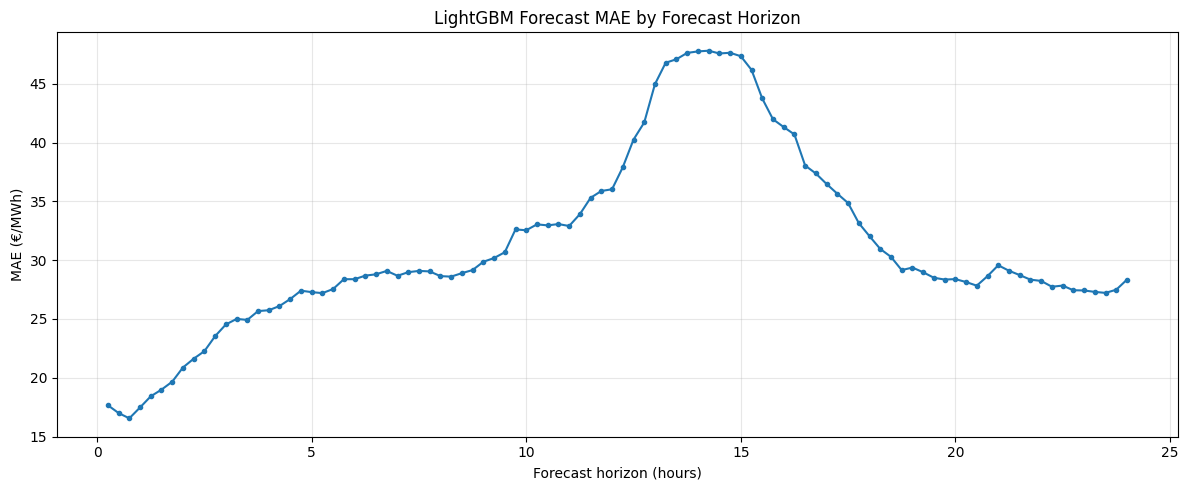

In [21]:
# ============================================================
# Forecast error by horizon
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    horizon_metrics["hours_ahead"],
    horizon_metrics["mae_eur_mwh"],
    marker="o",
    markersize=3
)

plt.title("LightGBM Forecast MAE by Forecast Horizon")
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("MAE (€/MWh)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

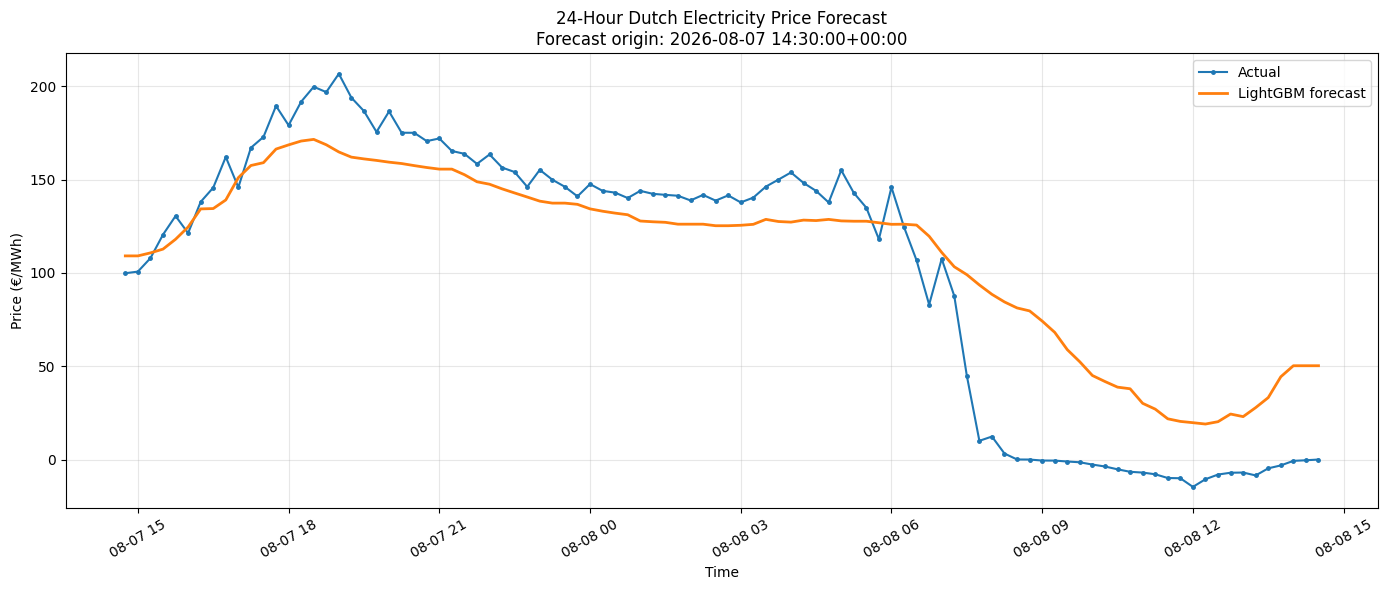

In [22]:
# ============================================================
# Example 24-hour forecast
# ============================================================

example_origin = (
    test_supervised["origin_timestamp"]
    .iloc[0]
)


example_forecast = (
    test_supervised[
        test_supervised["origin_timestamp"] == example_origin
    ]
    .copy()
    .sort_values("forecast_horizon")
)


example_forecast["forecast_time"] = (
    example_forecast["origin_timestamp"]
    + pd.to_timedelta(
        example_forecast["forecast_horizon"] * FREQUENCY_MINUTES,
        unit="min"
    )
)


plt.figure(figsize=(14, 6))

plt.plot(
    example_forecast["forecast_time"],
    example_forecast["target_price"],
    marker="o",
    markersize=2.5,
    linewidth=1.5,
    label="Actual"
)

plt.plot(
    example_forecast["forecast_time"],
    example_forecast["predicted_price"],
    linewidth=2,
    label="LightGBM forecast"
)

plt.title(
    f"24-Hour Dutch Electricity Price Forecast\n"
    f"Forecast origin: {example_origin}"
)

plt.xlabel("Time")
plt.ylabel("Price (€/MWh)")

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Save forecasting results
# ============================================================

forecast_output = test_supervised[
    [
        "origin_timestamp",
        "forecast_horizon",
        "target_price",
        "predicted_price",
        "naive_price"
    ]
].copy()


forecast_output.to_csv(
    FORECAST_FILE,
    index=False
)


print("Forecast results saved:")
print(FORECAST_FILE)

print("\nRows saved:")
print(len(forecast_output))

print("\nColumns:")
print(forecast_output.columns.tolist())

Forecast results saved:
C:\Users\USER\dutch-bess-flexibility-commercial-value-intelligence\results\price_forecast_24h_lightgbm.csv

Rows saved:
86976

Columns:
['origin_timestamp', 'forecast_horizon', 'target_price', 'predicted_price', 'naive_price']


In [24]:
# BESS arbitrage signal

SIGNAL_THRESHOLD_EUR_MWH = 10.0
SIGNAL_HORIZON_INTERVALS = 16  # next 4 hours

signal_df = test_supervised.copy()

current_prices = test_origins[
    ["timestamp_utc", PRICE_COL]
].rename(
    columns={PRICE_COL: "current_price"}
)

signal_df = signal_df.merge(
    current_prices,
    left_on="origin_timestamp",
    right_on="timestamp_utc",
    how="left"
)

next_4h_forecast = (
    signal_df[
        signal_df["forecast_horizon"] <= SIGNAL_HORIZON_INTERVALS
    ]
    .groupby("origin_timestamp")["predicted_price"]
    .mean()
    .rename("forecast_next_4h_mean")
)

signal_df = signal_df.merge(
    next_4h_forecast,
    left_on="origin_timestamp",
    right_index=True,
    how="left"
)

# Positive = expected future price is higher than current price
signal_df["expected_price_change"] = (
    signal_df["forecast_next_4h_mean"]
    - signal_df["current_price"]
)

# BESS arbitrage interpretation:
# future price sufficiently higher -> charge now
# future price sufficiently lower -> discharge now
signal_df["signal"] = np.select(
    [
        signal_df["expected_price_change"] >= SIGNAL_THRESHOLD_EUR_MWH,
        signal_df["expected_price_change"] <= -SIGNAL_THRESHOLD_EUR_MWH,
    ],
    [
        "BUY",
        "SELL",
    ],
    default="WAIT"
)

signal_summary = (
    signal_df[
        [
            "origin_timestamp",
            "current_price",
            "forecast_next_4h_mean",
            "expected_price_change",
            "signal",
        ]
    ]
    .drop_duplicates("origin_timestamp")
    .sort_values("origin_timestamp")
    .reset_index(drop=True)
)

print("Corrected BESS trading signal")
print("=" * 50)
print(signal_summary.head(10))

print("\nSignal counts")
print(signal_summary["signal"].value_counts())

print("\nSignal percentages")
print(
    signal_summary["signal"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Corrected BESS trading signal
           origin_timestamp  current_price  forecast_next_4h_mean  \
0 2026-08-07 14:30:00+00:00          86.34             139.789225   
1 2026-08-07 14:45:00+00:00          99.81             141.485753   
2 2026-08-07 15:00:00+00:00         100.68             146.931890   
3 2026-08-07 15:15:00+00:00         107.89             156.809408   
4 2026-08-07 15:30:00+00:00         120.48             157.561383   
5 2026-08-07 15:45:00+00:00         130.47             165.974027   
6 2026-08-07 16:00:00+00:00         121.31             177.812524   
7 2026-08-07 16:15:00+00:00         138.04             160.465341   
8 2026-08-07 16:30:00+00:00         145.65             169.439935   
9 2026-08-07 16:45:00+00:00         162.09             174.664203   

   expected_price_change signal  
0              53.449225    BUY  
1              41.675753    BUY  
2              46.251890    BUY  
3              48.919408    BUY  
4              37.081383    BUY  
5     